# Computer Vision basic

In [ ]:
! pip install tensorflow
! pip install opencv-python

^C


  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached charset_normalizer-3.5.1-cp312-cp312-win_amd64.whl.metadata (46 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.9 MB 2.6 MB/s eta 0:02:13
   ---------------------------------------- 1.8/350.9 MB 3.1 MB/s eta 0:01:51
   ---------------------------------------- 2.4/350.9 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 3.1/350.9 MB 3.3 MB/s e

In [19]:
import cv2 # do to image
import matplotlib.pyplot as plt # plot
import os

In [20]:
PATH = os.path.dirname(os.path.dirname(os.getcwd()))
IMAGE_PATH = os.path.join(PATH, r"data\raw\Training & Education Data\CV\test_1.jpg")
img = cv2.imread(IMAGE_PATH)
cv2.imshow("image" , img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [4]:
if img is None:
    raise FileNotFoundError(f"could not find image at: {IMAGE_PATH}")
else:
    print(f"image found succesfully")
    print(f"image shape: {img.shape}")

image found succesfully
image shape: (451, 680, 3)


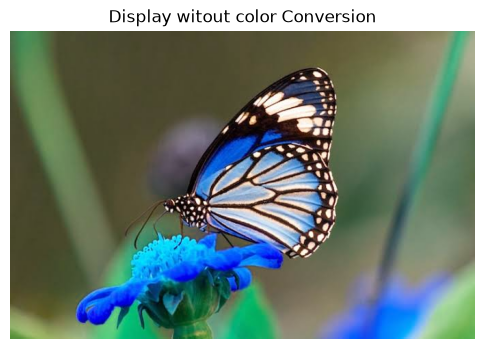

In [24]:
plt.figure(figsize=(6, 6))

plt.imshow(img)
# opencv read BGR no RGB
# matplotlib plot RGB bo BGR

plt.title("Display witout color Conversion")
plt.axis("off")
plt.show()

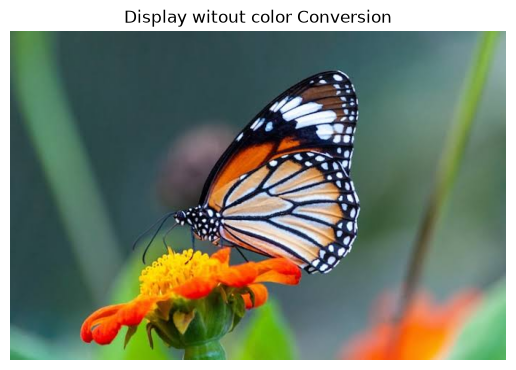

In [23]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
# opencv read BGR no RGB
# matplotlib plot RGB bo BGR

plt.title("Display witout color Conversion")
plt.axis("off")
plt.show()

Noise and normalize

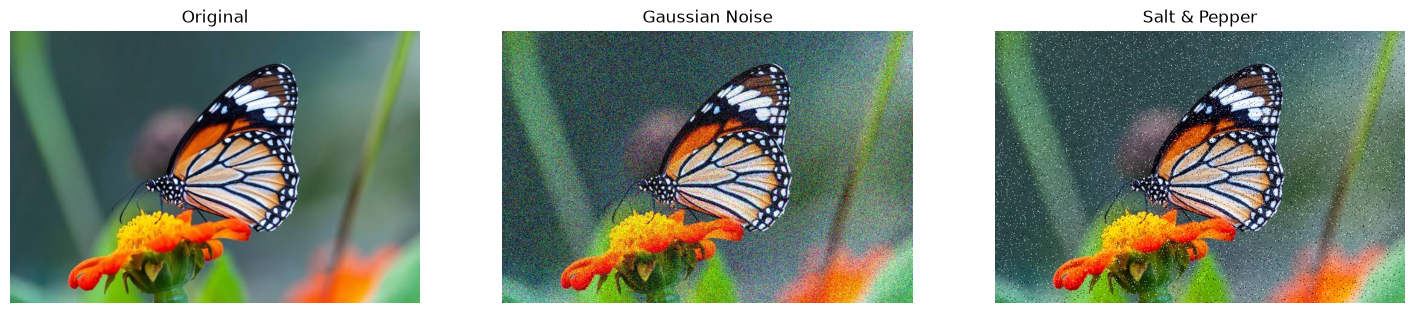

In [33]:
img = plt.imread(IMAGE_PATH)
img = img / 255.0


def gaussian(img, std=0.1):
    return np.clip(img + np.random.normal(0, std, img.shape), 0, 1)



def salt_pepper(img, amount=0.03):
    noisy = img.copy()
    h, w = h, w = img.shape[:2]
    num = int(amount * h * w)

    # random positions
    ys = np.random.randint(0, h, num)
    xs = np.random.randint(0, w, num)

    # half salt (white), half pepper (black)
    half = num // 2
    noisy[ys[:half], xs[:half]] = 1
    noisy[ys[half:], xs[half:]] = 0
    return noisy

# Create noisy images
g = gaussian(img, std=0.15)
sp = salt_pepper(img, amount=0.05)

# Show results
plt.figure(figsize=(18, 6))

for i, (title, im) in enumerate([
    ("Original", img),
    ("Gaussian Noise", g),
    ("Salt & Pepper", sp)
]):
    plt.subplot(1, 3, i+1)
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")

plt.show()


## thresholding

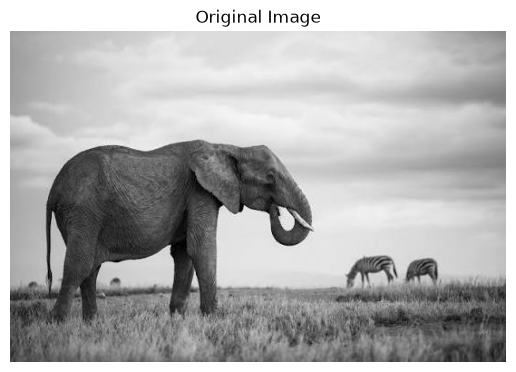

In [76]:
import cv2
import matplotlib.pyplot as plt
IMAGE_PATH = os.path.join(PATH, r"data\raw\Training & Education Data\CV\test_2.jpg")
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()


number of threshold: 180.0


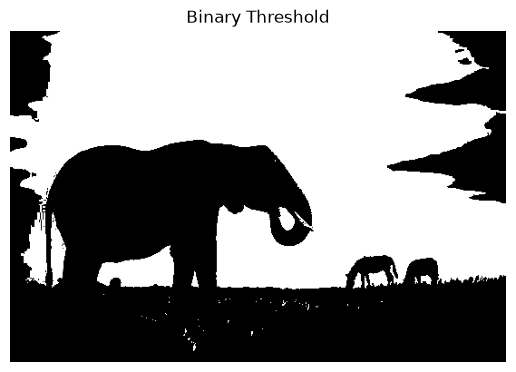

In [77]:
_, th = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

print(f"number of threshold: {_}")

plt.imshow(th, cmap='gray', vmin=0, vmax=255)
plt.title("Binary Threshold")
plt.axis("off")
plt.show()

number of threshold: 127.0


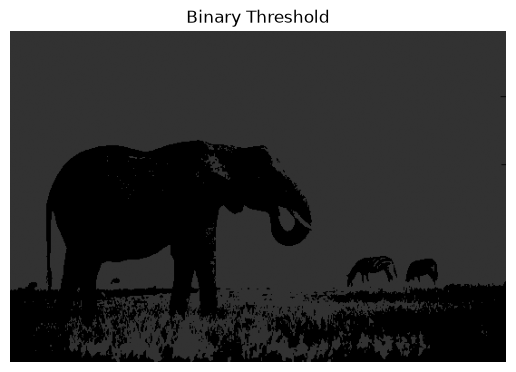

In [78]:
_, th = cv2.threshold(img, 127, 50, cv2.THRESH_BINARY)

print(f"number of threshold: {_}")

plt.imshow(th, cmap='gray', vmin=0, vmax=255)
plt.title("Binary Threshold")
plt.axis("off")
plt.show()

number of threshold: 127.0


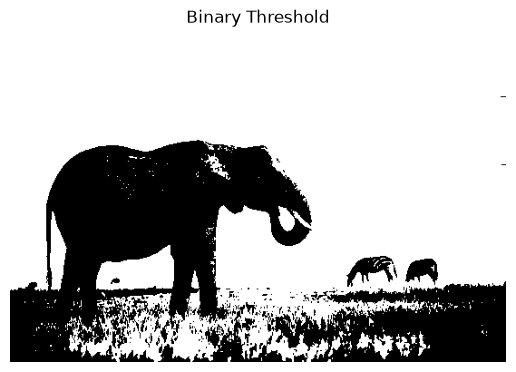

In [79]:
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

print(f"number of threshold: {_}")

plt.imshow(th, cmap='gray', vmin=0, vmax=255)
plt.title("Binary Threshold")
plt.axis("off")
plt.show()

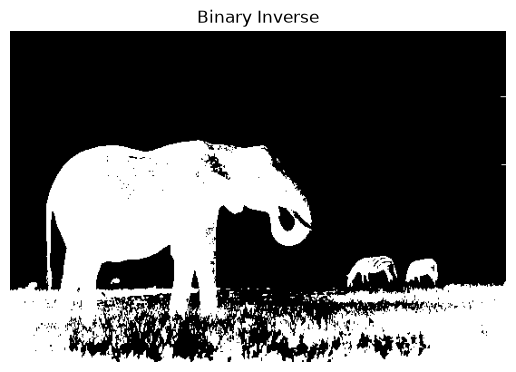

In [80]:
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

plt.imshow(th, cmap='gray')
plt.title("Binary Inverse")
plt.axis("off")
plt.show()


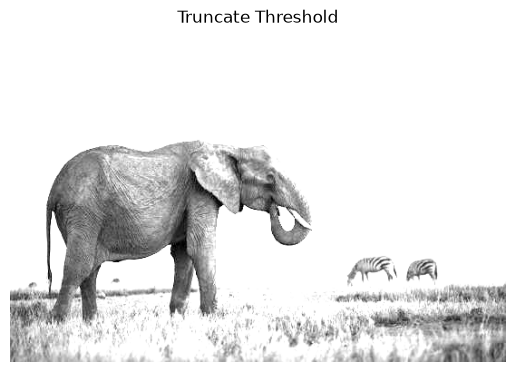

In [81]:
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)

plt.imshow(th, cmap='gray')
plt.title("Truncate Threshold")
plt.axis("off")
plt.show()


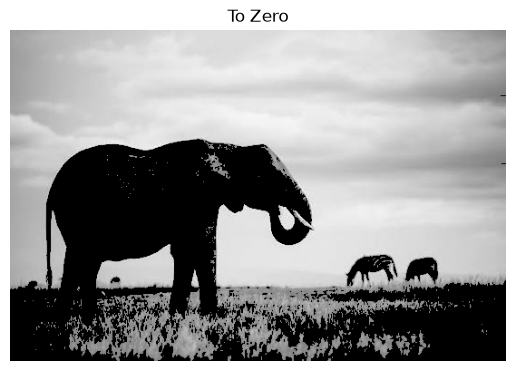

In [82]:
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)

plt.imshow(th, cmap='gray')
plt.title("To Zero")
plt.axis("off")
plt.show()


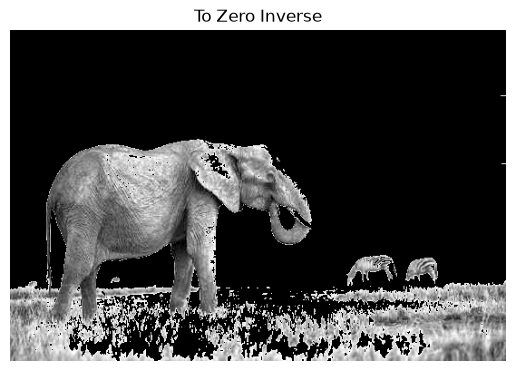

In [83]:
_, th = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)

plt.imshow(th, cmap='gray')
plt.title("To Zero Inverse")
plt.axis("off")
plt.show()


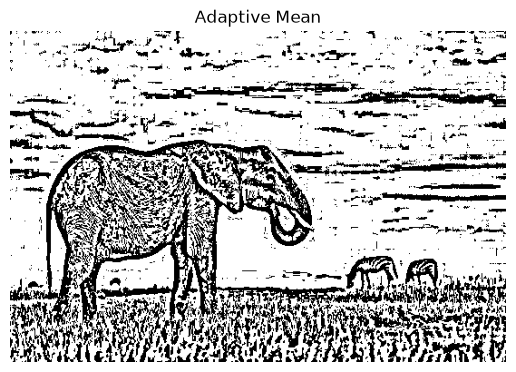

In [84]:

th = cv2.adaptiveThreshold(
    img, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.imshow(th, cmap='gray')
plt.title("Adaptive Mean")
plt.axis("off")
plt.show()


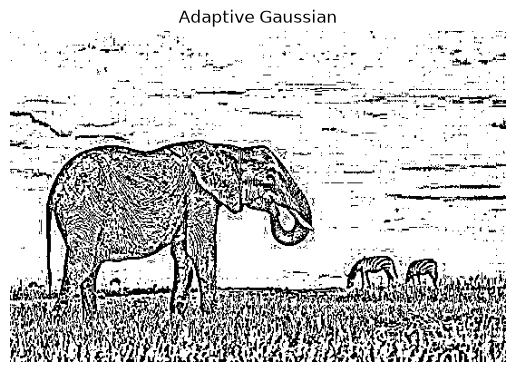

In [85]:
th = cv2.adaptiveThreshold(
    img, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.imshow(th, cmap='gray')
plt.title("Adaptive Gaussian")
plt.axis("off")
plt.show()


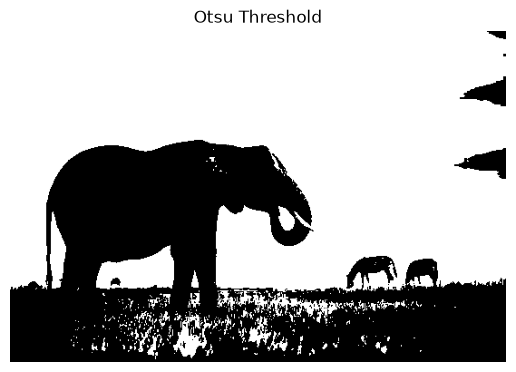

In [86]:
_, th = cv2.threshold(
    img, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(th, cmap='gray')
plt.title("Otsu Threshold")
plt.axis("off")
plt.show()


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers , models
import matplotlib.pyplot as plt
import os


In [3]:
PATH = os.path.dirname(os.path.dirname(os.getcwd()))
mnist_PATH = os.path.join(PATH, r"data\raw\Training & Education Data\CV\mnist.npz")
with np.load(mnist_PATH) as f:
    x_train, y_train = f["x_train"], f["y_train"]
    x_test, y_test = f["x_test"], f["y_test"]


In [ ]:
# from tensorflow.keras import datasets
# (x_train, y_train),(x_test, y_test) = datasets.mnist.load_data()

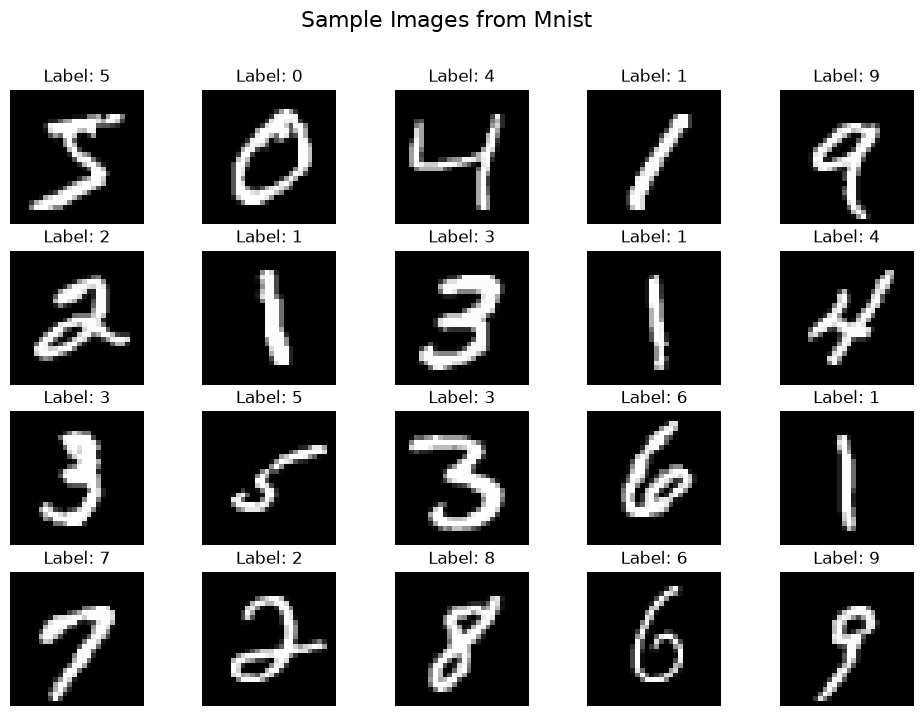

In [4]:
plt.figure(figsize=(12,8))
wight = 4
hight = 5
for i in range(wight * hight):
  plt.subplot(wight, hight, i + 1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis('off')

plt.suptitle("Sample Images from Mnist", fontsize=16)
plt.show()


In [ ]:
x_train = x_train /255.0
x_test = x_test / 255.0
# add 4th D
x_train = x_train[... , np.newaxis]
x_test = x_test[... , np.newaxis]


In [ ]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
x_train[... , np.newaxis]

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [9]:
x_train.shape , x_train[... , np.newaxis].shape

((60000, 28, 28), (60000, 28, 28, 1))

In [11]:
# Model
# from tensorflow.keras import layers , models

model=models.Sequential([
    # 32 filter, shape 3*3, activation func, input_shape shape of input
    layers.Conv2D(32, (3,3) , activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

In [ ]:
# pipline for run model
# optimizer aand upadate by adam
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [15]:
# fit model by train
history=model.fit(x_train, y_train, epochs=5 , batch_size=128, validation_data=(x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9905 - loss: 0.0287 - val_accuracy: 0.9812 - val_loss: 0.0748
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9921 - loss: 0.0241 - val_accuracy: 0.9839 - val_loss: 0.0612
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 0.9850 - val_loss: 0.0608
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9866 - val_loss: 0.0503
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9830 - val_loss: 0.0728


In [17]:
test_loss , test_acc = model.evaluate(x_test , y_test , verbose=1)
print(f"\n Final Test Acc: {test_acc: .4f}")
print(f"\n Final Test Loss: {test_loss: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9830 - loss: 0.0728

 Final Test Acc:  0.9830

 Final Test Loss:  0.0728


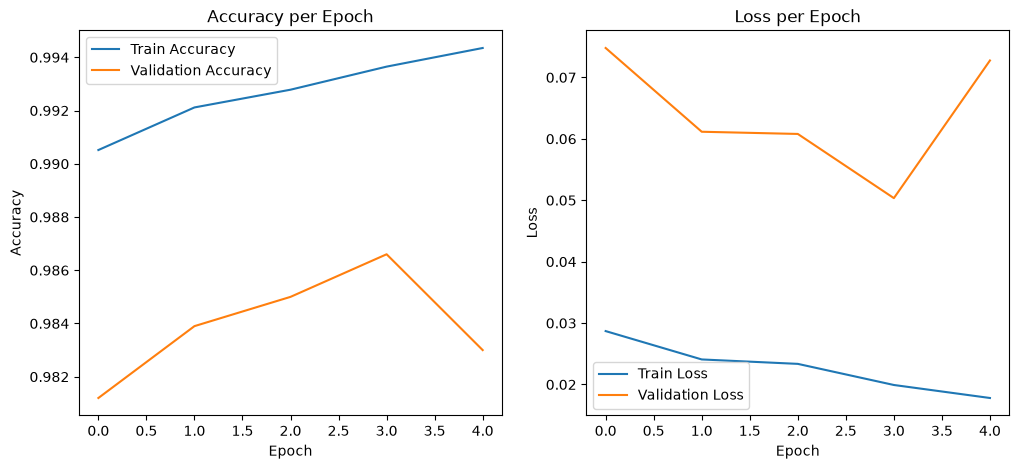

In [19]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()

plt.show()


In [20]:
predictions=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[6.9147340e-12 4.5250321e-11 1.0000000e+00 2.9540153e-13 5.1162126e-18
 7.7180511e-19 4.8898307e-16 1.8298609e-16 9.2313462e-11 1.3838675e-16]
--------------------------------------------------
max rate : 1.0, Number is: 2


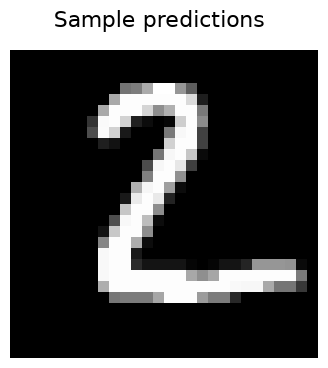

In [33]:
print(predictions[1])
print("".center(50,"-"))
print(f"max rate : {predictions[1].max()}, Number is: {np.argmax(predictions[1])}")
plt.figure(figsize=(4,4))
plt.imshow(x_test[1], cmap='gray')
plt.axis('off')

plt.suptitle("Sample predictions", fontsize=16)
plt.show()

In [34]:
y_pred = np.argmax(predictions, axis=1)

Predicted Probabilities [7.7397155e-09 3.1883474e-10 6.2379268e-12 2.1503039e-16 2.1412500e-13
 9.9999988e-01 7.5224690e-08 2.7550176e-15 1.2896377e-09 3.4773308e-12]
Predicted Class: 5
True Class: 5


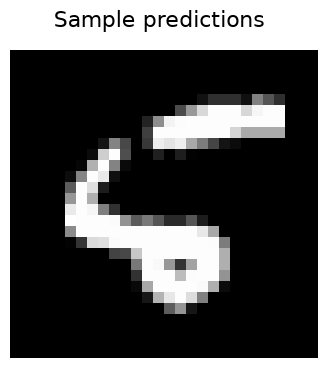

In [43]:
i= 8
print("Predicted Probabilities" , predictions[i])
print("Predicted Class:" , np.argmax(predictions[i]))
print("True Class:" , y_test[i])

plt.figure(figsize=(4,4))
plt.imshow(x_test[i], cmap='gray')
plt.axis('off')

plt.suptitle("Sample predictions", fontsize=16)
plt.show()


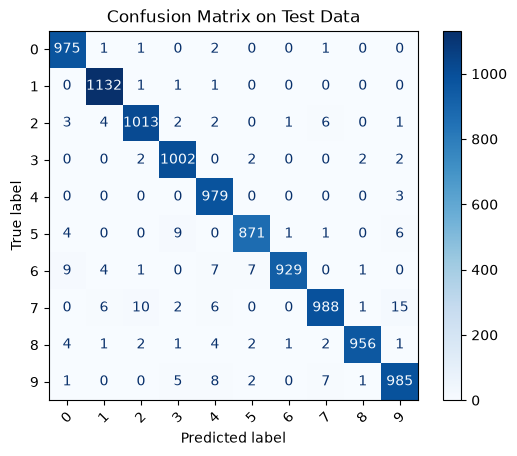

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Data")
plt.show()


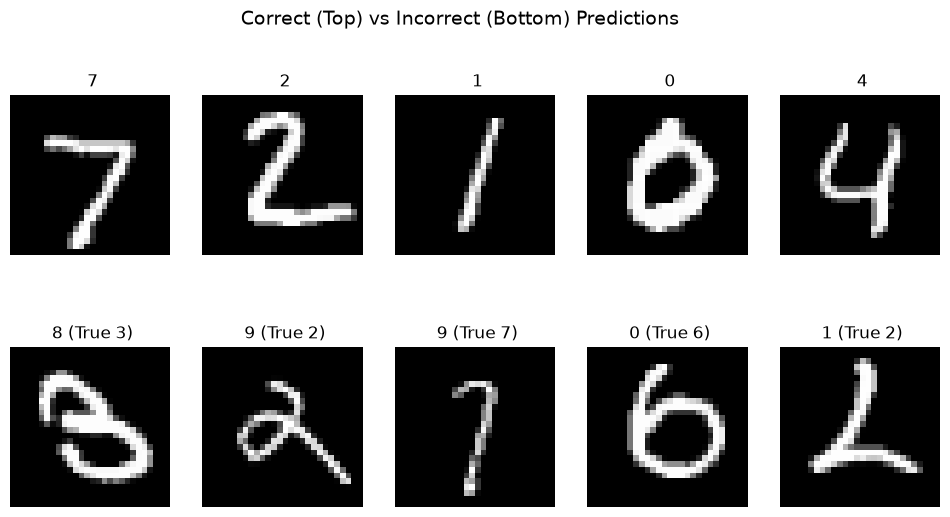

In [46]:

correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(correct_idx[:5]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f" {y_pred[idx]}")
    plt.axis('off')

for i, idx in enumerate(incorrect_idx[:5]):
    plt.subplot(2, 5, i+6)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f" {y_pred[idx]} (True {y_test[idx]})")
    plt.axis('off')

plt.suptitle("Correct (Top) vs Incorrect (Bottom) Predictions", fontsize=14)
plt.show()


In [ ]:
x_train_new , x_val , y_train_new, y_val=train_test_split(x_train,y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
print("training set:" , x_train_new.shape)
print("validation set:", x_val.shape)
print("test set:" , x_test.shape)

training set: (48000, 28, 28)
validation set: (12000, 28, 28)
test set: (10000, 28, 28)


In [ ]:
history=model.fit(x_train_new, y_train_new,epochs=5, validation_data=(x_val,y_val))